# ***Final Assignment: X-Ray images classification - XAI Analysis***
---
*   Meri Ferretti (10666970)
*   Diana Nigrisoli (10824967)
*   Laura Pozzi (10868694)

In this script all the steps related to ***Explainable AI*** will be illustrated. The following methods are investigated: 


*   GradCam
*   LIME
*   Occlusion Method






---

## Mounting | Importing | Seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Applied_AI_Project

/content/drive/MyDrive/Applied_AI_Project


In [ ]:
# Set up the environment
import numpy as np
import sys
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Flatten,Input,Lambda,GlobalAveragePooling2D,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Input,Activation
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array,array_to_img
from tensorflow.keras.optimizers import Adam,RMSprop,SGD
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os
import math
from tensorflow.keras.regularizers import l2
import json
import random
import tarfile
import seaborn as sns
plt.rc('font', size=16) 

import tensorflow as tf
import numpy as np
import os
import random
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

import cv2
import os


tfk = tf.keras
tfkl = tf.keras.layers

In [ ]:
### Random seed for reproducibility
seed = 42   
#42 because it is "the meaning of life, the universe, and everything"

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.compat.v1.set_random_seed(seed)

## Load Model & Data directory

In [ ]:
#Directories for data
normal_dir = '/content/drive/MyDrive/Applied_AI_Project/Dataset_op2_NoLetters/Test/Normal'
tube_dir = '/content/drive/MyDrive/Applied_AI_Project/Dataset_op2_NoLetters/Test/Tuberculosis'
pneumo_dir = '/content/drive/MyDrive/Applied_AI_Project/Dataset_op2_NoLetters/Test/Pneumonia'

In [ ]:
#Load the model to perform XAI with
xai_model = load_model('/content/drive/MyDrive/Applied_AI_Project/best_model_AI_assignment')

In [ ]:
xai_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 efficientnetb3 (Functional)  (None, 8, 8, 1536)       10783535  
                                                                 
 dropout (Dropout)           (None, 8, 8, 1536)        0         
                                                                 
 global_average_pooling2d (G  (None, 1536)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout_1 (Dropout)         (None, 1536)              0         
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                             

## Data Preprocessing Functions

In [ ]:
def check_noise_single(image):

    noisy = False

    roi1 = image[224:224+10, 243:243+10] 
    std1 = roi1.std()
    
    roi2 = image[243:243+10, 4:4+10]
    std2 = roi2.std()
  
    roi3 = image[32:32+10, 4:4+10] 
    std3 = roi3.std()
    
    roi4 = image[4:4+10, 243:243+10]
    std4 = roi4.std()

    roi5 = image[120:120+10, 4:4+10] 
    std5 = roi5.std()

    roi6 = image[120:120+10, 243:243+10] 
    std6 = roi6.std()

    if (std1>20 and std2>20 and std3>20 and std4>20 and std5>20 and std6>20):
      noisy = True
    
    return noisy


def equalize(image):

  grayimg = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  grayimg = np.uint8(grayimg)
  # Equalizing each channel individually
  image_eq = cv2.equalizeHist(grayimg)
 
  # Stacking the equalized channels back into a single image
  image_equal = np.stack((image_eq,image_eq,image_eq), axis=2)

  return image_equal

def preprocess_function(image):
  noisy = check_noise_single(image)
  if noisy :
    image = cv2.medianBlur(image, 5)
    image = equalize(image)
  else: 
    image = equalize(image) 
  return image

## XAI methods

### GradCam





In [ ]:
import cv2

def GradCam(model, img_array, layer_name, label, eps=1e-25):
    '''
    Creates a grad-cam heatmap given a model and a layer name contained with that model
    
    Args:
      model: tf model
      img_array: (img_width x img_width) numpy array
      layer_name: str


    Returns 
      uint8 numpy array with shape (img_height, img_width)
    '''

    # define a model which is equal to the model used to 
    # perform classification but truncated to the last convolutional layer from
    # which we will then extract the activation maps
    gradModel = Model(
			inputs=[model.inputs],
			outputs=[model.get_layer(layer_name).output,
			model.output])
    
    with tf.GradientTape() as tape:
			# cast the image tensor to a float-32 data type, pass the
			# image through the gradient model, and grab the loss
			# associated with the specific class index
      inputs = tf.cast(img_array, tf.float32) # we use the preprocessed image
      (convOutputs, predictions) = gradModel(inputs)
      loss = predictions[:, np.argmax(label)]
		# use automatic differentiation to compute the gradients related to the 
    # previously selected last convolutional layer 
    grads = tape.gradient(loss, convOutputs)
    
    # compute the guided gradients
    castConvOutputs = tf.cast(convOutputs > 0, "float32")
    castGrads = tf.cast(grads > 0, "float32")
    guidedGrads = castConvOutputs * castGrads * grads
		# the convolution and guided gradients have a batch dimension
		# (which we don't need) so let's grab the volume itself and
		# discard the batch
    convOutputs = convOutputs[0]
    guidedGrads = guidedGrads[0]
    # compute the average of the gradient values among all the feature maps of 
    # the last convolutional layer obtaining a single map of average gradients 
    # that will be considered as map of weights
    weights = tf.reduce_mean(guidedGrads, axis=(0, 1))
    # compute the channel-wise sum of the filters previously multiplied 
    # by the weights map obtaining a single feature map that will become our heatmap
    cam = tf.reduce_sum(tf.multiply(weights, convOutputs), axis=-1)
  
    # grab the spatial dimensions of the input image and resize
		# the output class activation map to match the input image dimensions
    (w, h) = (img_array.shape[2], img_array.shape[1])
    heatmap = cv2.resize(cam.numpy(), (w, h))
		# normalize the heatmap such that all values lie in the range
		# [0, 1], scale the resulting values to the range [0, 255]
    numer = heatmap - np.min(heatmap)
    denom = (heatmap.max() - heatmap.min()) + eps
    heatmap = numer / denom

		# return the resulting heatmap to the calling function
    return heatmap,predictions



In [ ]:
def sigmoid(x, a, b, c):
  return c / (1 + np.exp(-a * (x-b)))
  
def display_gradcam(img_path, heatmap):
    # Load the original image
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))

    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

Analysis on a single image

In [ ]:
#Load of the image, preprocess and reshape 
image_path = os.path.join(pneumo_dir,'P07675_2.jpeg')
image= cv2.imread(image_path)
xai_image=preprocess_function(image)
xai_image =cv2.resize(xai_image, (256,256))
xai_img = np.expand_dims(xai_image, axis=0)
xai_img.shape

(1, 256, 256, 3)

In [ ]:
#check the predicted class
classe = xai_model.predict(xai_img)
print(np.argmax(classe))

1/1 [==============================] - 0s 29ms/step
1


In [ ]:
layer_name = 'dropout' #layer of the CNN 
label = [0, 1, 0] #class for computing GradCam 

grad_cam,predictions=GradCam(xai_model, xai_img, layer_name, label)

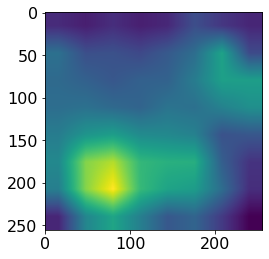

In [ ]:
plt.imshow(grad_cam)

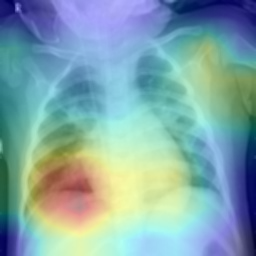

In [ ]:
display_gradcam(image_path, grad_cam)

### LIME

In [ ]:
!pip install lime 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import lime
from lime import lime_image
from lime import submodular_pick

from skimage.segmentation import mark_boundaries

In [ ]:
def generate_prediction_sample(exp, exp_class, weight = 0.05, show_positive = True, hide_background = True):
    '''
    Method to display and highlight super-pixels used by the black-box model to make predictions

    Args:
      exp: Lime image explainer
      exp_class: predictions of model
      weight: float for showing lime boundaries
      show_positive and hide_backrgound: booleans for image plot settings


    Returns 
      ndarray array with shape (img_height, img_width, channels)

    '''
    image, mask = exp.get_image_and_mask(exp_class, 
                                         positive_only=show_positive, 
                                         num_features=6, 
                                         hide_rest=hide_background,
                                         min_weight=weight
                                        )
    return mark_boundaries(image, mask, color=(255, 0, 0))
    

def explanation_heatmap(exp, exp_class):
    '''
    Using heat-map to highlight the importance of each super-pixel for the model prediction
    '''
    dict_heatmap = dict(exp.local_exp[exp_class])
    heatmap = np.vectorize(dict_heatmap.get)(exp.segments) 
    plt.imshow(heatmap, cmap = 'RdBu', vmin  = -heatmap.max(), vmax = heatmap.max())
    plt.colorbar()
    plt.show()

#functions taken from: https://towardsdatascience.com/how-to-explain-image-classifiers-using-lime-e364097335b4

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
#Load of the image, preprocess and reshape 
image_path = os.path.join(pneumo_dir,'P07675_2.jpeg')
image = cv2.imread(image_path)
xai_image =preprocess_function(image)
xai_image =cv2.resize(xai_image, (256,256))
xai_img = np.expand_dims(xai_image, axis=0)

In [ ]:
exp = explainer.explain_instance(
                                 xai_img[0,:,:,:],
                                 xai_model.predict,
                                 top_labels=3, 
                                 hide_color=0, 
                                 num_samples=1000,
                                 )

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 34ms/step


In [ ]:
print(exp.top_labels)

[1, 0, 2]


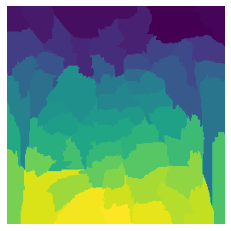

In [ ]:
plt.imshow(exp.segments)
plt.axis('off')
plt.show()

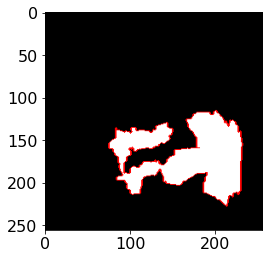

In [ ]:
plt.imshow(generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = True))

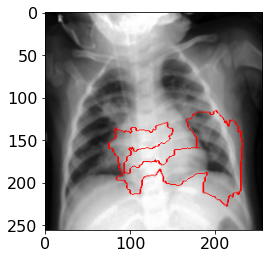

In [ ]:
plt.imshow(generate_prediction_sample(exp, exp.top_labels[0], show_positive = True, hide_background = False))

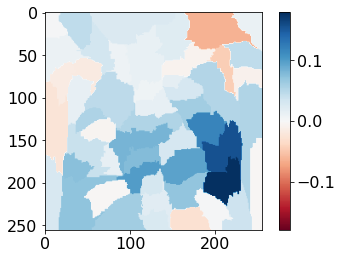

In [ ]:
explanation_heatmap(exp, exp.top_labels[0])

### Occlusion Method

In [ ]:
def Occlusion_exp(model,im, occluding_size, occluding_pixel, occluding_stride):
  '''
    Method to display and highlight important regions used for predictions

    Args:
      model: deep learning model
      im: image 
      occluding_size: dimension of the occluding black box
      occluding_pixel: position of the occluding black box
      occluding_stride: stride between one occlusion and the following 

    Returns 
      ndarray heatmap, the shape will be defined by the occlunding size and stride

    '''
  
  out = model.predict(im)
  out = out[0]
  pred=out
  index_object = np.argmax(out)
  _, height, width, _ = im.shape
  heatmap = np.zeros(shape=(len(range(0,height-occluding_size+1, occluding_stride)), 
                            len(range(0, width-occluding_size+1, occluding_stride))))
  i=0
  j=0
  for h in range(0,height-occluding_size+1, occluding_stride):
      i=0
      for w in range(0, width-occluding_size+1, occluding_stride):
          # Occluder region:
          h_start = h 
          w_start = w 
          h_end = min(height, h_start + occluding_size)
          w_end = min(width, w_start + occluding_size)
          
          input_image = np.copy(im)
          input_image[0,h_start:h_end, w_start:w_end,:] =  occluding_pixel            
          
          # num_row = 1
          # num_col = 2 
          # fig, axes = plt.subplots(num_row, num_col)
          # ax_1 = axes[0]
          # ax_1.imshow(im[0,:,:,:])
          # ax_1 = axes[1]
          # ax_1.imshow(input_image[0,:,:,:])
          # plt.show()

          out = model.predict(input_image,verbose = 0)
          out = out[0]
          #print('scanning position (%s, %s)'%(h,w))
          
          prob = (out[index_object]) 
          heatmap[i,j] =pred[index_object]- prob  
          #print(prob)
          # print('scanning position (%s, %s) with prob: %s'%(h,w, prob))
          # print('position in heatmap (%s, %s)'%(i,j))

          i+=1
      j+=1
  return heatmap

In [ ]:
def display_occlusion(img, heatmap):
    # Rescale heatmap to a range 0-255
    heatmap = cv2.normalize(heatmap, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)
    heatmap = heatmap.astype(np.uint8)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.4 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img
  


In [ ]:
#Load of the image, preprocess and reshape 
image_path = os.path.join(pneumo_dir,'P07675_2.jpeg')
image= cv2.imread(image_path)
xai_image=preprocess_function(image)
xai_image =cv2.resize(xai_image, (256,256))
xai_img = np.expand_dims(xai_image, axis=0)
xai_img.shape

(1, 256, 256, 3)

In [ ]:
out=xai_model.predict(xai_img)
print(np.argmax(out))

1/1 [==============================] - 0s 31ms/step
1


In [ ]:
occluding_size = 64
occluding_pixel = 0
occluding_stride = 16

heatmap=Occlusion_exp(xai_model, xai_img, occluding_size, occluding_pixel, occluding_stride)

1/1 [==============================] - 0s 30ms/step


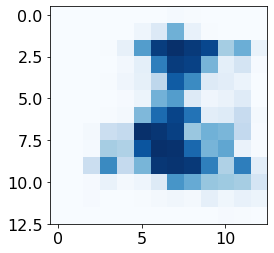

In [ ]:
plt.imshow(heatmap, 'Blues')

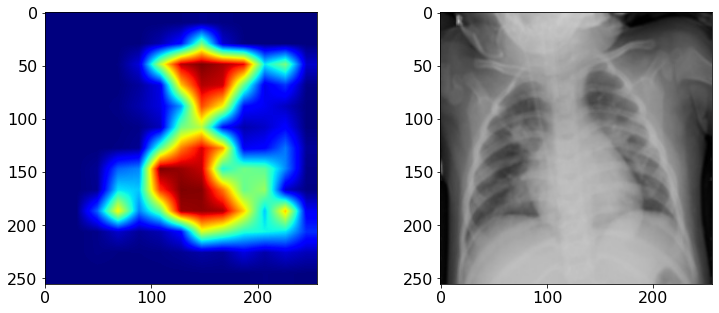

In [ ]:
f = plt.figure(figsize=(13,5))
f.add_subplot(1, 2, 1)  
plt.imshow(cv2.resize(heatmap, (256,256)), cmap='jet')
f.add_subplot(1, 2, 2)
plt.imshow(cv2.resize(image, (256,256)))
plt.show()

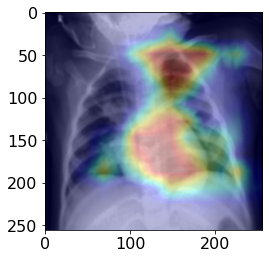

In [ ]:
plt.imshow(display_occlusion(xai_image, cv2.resize(heatmap, (256,256))))

## Analysis per class

In [ ]:
def load_image(image_name,dir):
  image_path = os.path.join(dir,image_name)
  image= cv2.imread(image_path)
  return image

def prepare_image(image):
  xai_img = np.expand_dims(image, axis=0)
  return image,xai_img

######################################################

def prepare_GRAD(xai_img,xai_model, code):
  preds = xai_model.predict(xai_img)
  max_pred = np.argmax(preds)
  print('code: {}, class: {} '.format(code,max_pred))
  array_pred = []
  for i in range(3):
    if i == max_pred : array_pred.append(1)
    else:  array_pred.append(0)
  layer_name = 'dropout'
  return array_pred,layer_name

def GRAD(image,xai_model, dir, img_code): 
  original,xai_img = prepare_image(image)
  array_pred,layer_name = prepare_GRAD(xai_img,xai_model, img_code)
  grad_cam,predictions=GradCam(xai_model, xai_img, layer_name, array_pred)
  image_path = os.path.join(dir,img_code)
  map=display_gradcam(image_path, grad_cam)
  return map

##############################################################
from functools import partial

def prepare_LIME(xai_img,xai_model):
  explainer = lime_image.LimeImageExplainer()
  exp = explainer.explain_instance(
                                 xai_img[0,:,:,:],
                                 partial(xai_model.predict, verbose=0),
                                 top_labels=3, 
                                 hide_color=0, 
                                 num_samples=1000)
  return exp,exp.top_labels

def LIME(image,xai_model):
  _,xai_img = prepare_image(image)
  exp,top_labels = prepare_LIME(xai_img,xai_model)
  return generate_prediction_sample(exp, top_labels[0], show_positive = True, hide_background = False)

#############################

def prepare_Occlusion(xai_img,xai_model):
  occluding_size = 64
  occluding_pixel = 0
  occluding_stride = 16
  heatmap=Occlusion_exp(xai_model, xai_img, occluding_size, occluding_pixel, occluding_stride)
  return heatmap
  
def OCCLUSION(image,xai_model):
  original,xai_img = prepare_image(image)
  heatmap = prepare_Occlusion(xai_img,xai_model)
  superimposed_img=display_occlusion(original, cv2.resize(heatmap, (256,256)))
  return superimposed_img

########

In [ ]:
images_to_plot = ['P14011_1.jpeg', 'P07675_2.jpeg', 'P11851_1.png'] #one image for every class

#### Normal

In [ ]:
image1=load_image(images_to_plot[0],normal_dir)
image1=preprocess_function(image1)

map_grad1 = GRAD(image1,xai_model, normal_dir, images_to_plot[0])
map_lime1 =LIME(image1,xai_model)
map_occlusion1 = OCCLUSION(image1,xai_model)

1/1 [==============================] - 0s 33ms/step
code: P14011_1.jpeg, class: 0 


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 39ms/step


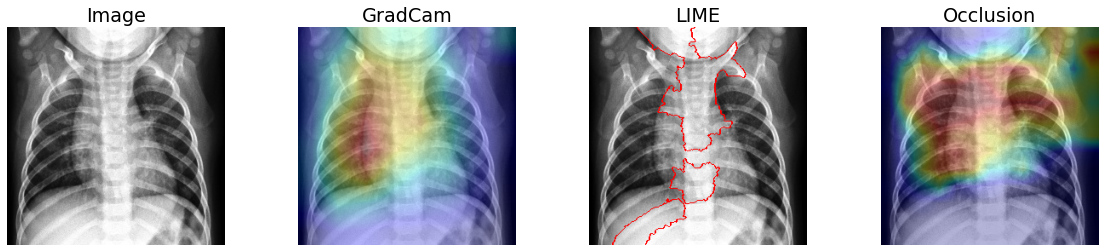

In [ ]:
num_row = 1
num_col = 4
fig, axes = plt.subplots(num_row, num_col, figsize=(5*num_col,4*num_row)) 

ax_0 = axes[0]
ax_0.imshow(image1)
ax_0.axis('off')

ax_1 = axes[1]
ax_1.imshow(map_grad1)
ax_1.axis('off')

ax_2 = axes[2]
ax_2.imshow(map_lime1)
ax_2.axis('off')

ax_3 = axes[3]
ax_3.imshow(map_occlusion1)
ax_3.axis('off')

ax_0.set_title('Image')
ax_1.set_title('GradCam')
ax_2.set_title('LIME')
ax_3.set_title('Occlusion')

plt.show()


#### Pneumonia

In [ ]:
image2=load_image(images_to_plot[1],pneumo_dir)
image2=preprocess_function(image2)

map_grad2 = GRAD(image2,xai_model, pneumo_dir, images_to_plot[1])
map_lime2 =LIME(image2,xai_model)
map_occlusion2 = OCCLUSION(image2,xai_model)

1/1 [==============================] - 0s 33ms/step
code: P07675_2.jpeg, class: 1 


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 36ms/step


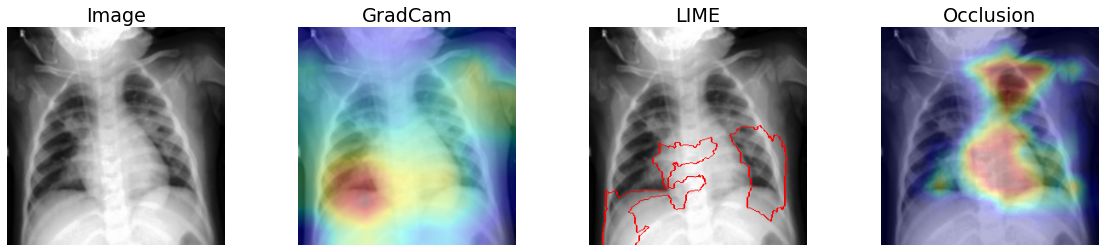

In [ ]:
num_row = 1
num_col = 4
fig, axes = plt.subplots(num_row, num_col, figsize=(5*num_col,4*num_row)) 

ax_0 = axes[0]
ax_0.imshow(image2)
ax_0.axis('off')

ax_1 = axes[1]
ax_1.imshow(map_grad2)
ax_1.axis('off')

ax_2 = axes[2]
ax_2.imshow(map_lime2)
ax_2.axis('off')

ax_3 = axes[3]
ax_3.imshow(map_occlusion2)
ax_3.axis('off')

ax_0.set_title('Image')
ax_1.set_title('GradCam')
ax_2.set_title('LIME')
ax_3.set_title('Occlusion')

plt.show()


#### Tuberculosis

In [ ]:
image3=load_image(images_to_plot[2],tube_dir)
image3=preprocess_function(image3) 

map_grad3 = GRAD(image3,xai_model, tube_dir, images_to_plot[2])
map_lime3 =LIME(image3,xai_model)
map_occlusion3 = OCCLUSION(image3,xai_model)

1/1 [==============================] - 0s 29ms/step
code: P11851_1.png, class: 2 


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 53ms/step


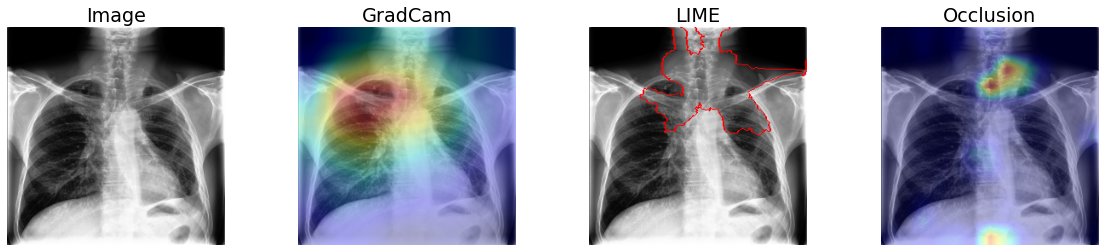

In [ ]:
num_row = 1
num_col = 4
fig, axes = plt.subplots(num_row, num_col, figsize=(5*num_col,4*num_row)) 

ax_0 = axes[0]
ax_0.imshow(image3)
ax_0.axis('off')

ax_1 = axes[1]
ax_1.imshow(map_grad3)
ax_1.axis('off')

ax_2 = axes[2]
ax_2.imshow(map_lime3)
ax_2.axis('off')

ax_3 = axes[3]
ax_3.imshow(map_occlusion3)
ax_3.axis('off')

ax_0.set_title('Image')
ax_1.set_title('GradCam')
ax_2.set_title('LIME')
ax_3.set_title('Occlusion')

plt.show()
